# 13 - Candidate to Split Provenance Workflow

**Current surface:** V0.29.

This tutorial is the candidate-validation recipe: start with a supplied generator candidate, run configured validation, summarize confidence, materialize a small translation orbit, and report split-provenance risk from user-supplied partition labels.

## What you will learn

- How supplied generator evidence differs from a proof of symmetry.
- How candidate validation and confidence reports keep evidence explicit.
- How materialized orbit provenance can reveal cross-partition overlap.
- Why PDELie reports split risk but does not create or enforce split policy.

## Required extras

Use `.[test]` or `.[viz]` for plotting. Core APIs are otherwise sufficient.

## Expected runtime

Less than one minute on a laptop.

## Out of scope

No split manager, leakage preventer, train/test policy, arbitrary finite group action, multi-generator fitting, or new runtime API is introduced here.


In [1]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np

from pdelie.data import generate_heat_1d_field_batch, split_batch_train_heldout
from pdelie.derivatives import compute_spectral_fd_derivatives
from pdelie.invariants import build_uniform_translation_orbit_batch
from pdelie.reporting import (
    summarize_generator_confidence,
    summarize_generator_fit_diagnostics,
    summarize_residual_batch,
    summarize_split_leakage_provenance,
    summarize_verification_report,
)
from pdelie.residuals import HeatResidualEvaluator
from pdelie.symmetry import fit_translation_generator, validate_symmetry_candidate
from pdelie.verification import verify_translation_generator


In [2]:
field = generate_heat_1d_field_batch(batch_size=6, num_times=33, num_points=64, seed=29029)
evaluator = HeatResidualEvaluator()
train, heldout = split_batch_train_heldout(field, train_size=3, seed=29030)

derivatives = compute_spectral_fd_derivatives(train)
residual = evaluator.evaluate(train, derivatives)
generator = fit_translation_generator(train, evaluator, epsilon=1e-4)
verification = verify_translation_generator(heldout, generator, evaluator)

candidate_validation = validate_symmetry_candidate(
    train,
    generator,
    residual_evaluator=evaluator,
    reference_generator=generator,
    finite_transform_epsilons=np.logspace(-4, -2, 5),
    source_candidate_id="supplied-translation-generator",
)
confidence = summarize_generator_confidence(
    residual=summarize_residual_batch(residual),
    generator=generator,
    fit_diagnostics=summarize_generator_fit_diagnostics(generator),
    verification=summarize_verification_report(verification),
    candidate_validation=candidate_validation,
    thresholds={"residual_rms": 1e-5, "verification_first_error": 5e-4},
)

print(json.dumps({
    "candidate_conclusion": candidate_validation["conclusion"],
    "configured_checks": candidate_validation["configured_validation_checks"],
    "confidence": confidence["confidence_label"],
    "fit_evidence": confidence["fit_diagnostics"]["evidence_label"],
}, indent=2))


{
  "candidate_conclusion": "validated",
  "configured_checks": [
    "schema",
    "finite_transform_verification",
    "reference_span_comparison"
  ],
  "confidence": "failed",
  "fit_evidence": "direct_svd_in_tolerance"
}


In [3]:
x = np.asarray(train.coords["x"], dtype=float)
domain_length = float(x.size * (x[1] - x[0]))
orbit = build_uniform_translation_orbit_batch(
    train,
    shifts=[0.0, domain_length],
    source_field_id="candidate-workflow-train-field",
)
partitions = ["train", "train", "heldout", "heldout", "train", "heldout"]
split_report = summarize_split_leakage_provenance(
    partitions=partitions,
    orbit_batch=orbit,
    source_ids=["source-0", "source-1", "source-2"],
    source_report_id="tutorial-user-supplied-partitions",
    extra_metrics={"workflow_recipe": "candidate_to_split_provenance", "release": "v0.29"},
)

print(json.dumps({
    "orbit_output_batch_size": orbit.report["output_batch_size"],
    "partition_counts": split_report["partition_counts"],
    "risk_label": split_report["risk_label"],
    "risk_reasons": split_report["risk_reasons"],
}, indent=2))


{
  "orbit_output_batch_size": 6,
  "partition_counts": {
    "train": 3,
    "heldout": 3
  },
  "risk_label": "traceable_overlap",
  "risk_reasons": [
    "source_overlap_across_partitions",
    "identity_shift_overlap_across_partitions"
  ]
}


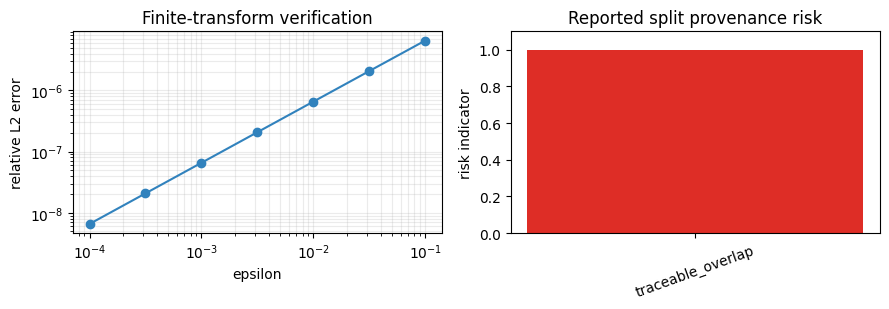

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
errors = confidence["verification"]["error_curve"]
epsilons = confidence["verification"]["epsilon_values"]
axes[0].loglog(epsilons, errors, marker="o", color="#3182bd")
axes[0].set_title("Finite-transform verification")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("relative L2 error")
axes[0].grid(True, which="both", alpha=0.25)

risk_to_value = {"no_detected_overlap": 0, "inconclusive": 0.5, "missing_provenance": 0.75, "traceable_overlap": 1.0}
axes[1].bar([split_report["risk_label"]], [risk_to_value[split_report["risk_label"]]], color="#de2d26")
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Reported split provenance risk")
axes[1].set_ylabel("risk indicator")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()


## Takeaway

A supplied candidate can pass configured validation and still require separate provenance reporting before orbit-expanded data is used downstream. V0.29 makes that recipe explicit without adding split policy or a new workflow helper.
